# LLM Annual Report Generation Challenge

## Objective

This notebook extracts the structure of a financial report and uses an LLM to generate a completely fictional annual report with fake financial data, charts, and references.

In [1]:
# Import libraries
import fitz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
# Path of the sample PDF

pdf_path = "input/sample_input_1 (1).pdf"

# Open the PDF

document = fitz.open(pdf_path)

print("Number of pages:", len(document))

Number of pages: 5


In [3]:
# Extract text from every page

all_text = ""

for page in document:
    all_text += page.get_text()

print(all_text[:1000])

 
 
 
 
11th September 2023 
Q1FY24 RESULTS UPDATE 
Retail Equity Research 
Tata Power Company Limited 
Electric Utilities 
BSE CODE: 500400 
 
NSE CODE: TATAPOWER 
Bloomberg CODE: TPWR:IN  
SENSEX: 67,127 
12 Months Investment Period            Rating as per Large Cap 
CMP Rs. 272        TARGET Rs. 301        RETURN 11% 
(Closing: 11-09-23) 
KEY CHANGES:                             TARGET                                                    RATING                                                 EARNINGS 
BUY 
www.geojit.com
Moderate growth in revenue  
Consolidated revenue grew 5.0% YoY to Rs. 15,213cr in Q1FY24, led by growth of 3.6% 
YoY in the transmission and distribution business. The Odisha business stabilised on 
the back of various restoration and field activities to overcome uncertain weather 
conditions.  The generation business grew a significant 67.5% on a QoQ basis due to 
improved cost control and better efficiency. The Mundra plant aided performance 
during the quarter an

# Step 4 - Analyze PDF Structure

In [4]:
# Print first 5000 characters

print(all_text[:5000])

 
 
 
 
11th September 2023 
Q1FY24 RESULTS UPDATE 
Retail Equity Research 
Tata Power Company Limited 
Electric Utilities 
BSE CODE: 500400 
 
NSE CODE: TATAPOWER 
Bloomberg CODE: TPWR:IN  
SENSEX: 67,127 
12 Months Investment Period            Rating as per Large Cap 
CMP Rs. 272        TARGET Rs. 301        RETURN 11% 
(Closing: 11-09-23) 
KEY CHANGES:                             TARGET                                                    RATING                                                 EARNINGS 
BUY 
www.geojit.com
Moderate growth in revenue  
Consolidated revenue grew 5.0% YoY to Rs. 15,213cr in Q1FY24, led by growth of 3.6% 
YoY in the transmission and distribution business. The Odisha business stabilised on 
the back of various restoration and field activities to overcome uncertain weather 
conditions.  The generation business grew a significant 67.5% on a QoQ basis due to 
improved cost control and better efficiency. The Mundra plant aided performance 
during the quarter an

# Step 5 - Extract Basic Information

In [5]:
import re

# Extract company name
company_match = re.search(r"Tata Power Company Limited", all_text)

if company_match:
    company_name = company_match.group()
else:
    company_name = "Not Found"

print("Company Name:", company_name)

Company Name: Tata Power Company Limited


# Step 6 - Dynamic Company Name Extraction

In [6]:
# Split the PDF text into individual lines

lines = all_text.split("\n")

# Display the first 20 lines

for i, line in enumerate(lines[:20]):
    print(i, ":", line)

0 :  
1 :  
2 :  
3 :  
4 : 11th September 2023 
5 : Q1FY24 RESULTS UPDATE 
6 : Retail Equity Research 
7 : Tata Power Company Limited 
8 : Electric Utilities 
9 : BSE CODE: 500400 
10 :  
11 : NSE CODE: TATAPOWER 
12 : Bloomberg CODE: TPWR:IN  
13 : SENSEX: 67,127 
14 : 12 Months Investment Period            Rating as per Large Cap 
15 : CMP Rs. 272        TARGET Rs. 301        RETURN 11% 
16 : (Closing: 11-09-23) 
17 : KEY CHANGES:                             TARGET                                                    RATING                                                 EARNINGS 
18 : BUY 
19 : www.geojit.com


In [7]:
# Remove blank lines

clean_lines = []

for line in lines:
    line = line.strip()      # Remove extra spaces
    if line != "":           # Keep only non-empty lines
        clean_lines.append(line)

# Print first 15 clean lines
for i, line in enumerate(clean_lines[:15]):
    print(i, ":", line)

0 : 11th September 2023
1 : Q1FY24 RESULTS UPDATE
2 : Retail Equity Research
3 : Tata Power Company Limited
4 : Electric Utilities
5 : BSE CODE: 500400
6 : NSE CODE: TATAPOWER
7 : Bloomberg CODE: TPWR:IN
8 : SENSEX: 67,127
9 : 12 Months Investment Period            Rating as per Large Cap
10 : CMP Rs. 272        TARGET Rs. 301        RETURN 11%
11 : (Closing: 11-09-23)
12 : KEY CHANGES:                             TARGET                                                    RATING                                                 EARNINGS
13 : BUY
14 : www.geojit.com


# Step 7 - Extract Document Structure

In [8]:
import re

headings = []

for line in clean_lines:
    line = line.strip()

    # Detect likely headings
    if (
        len(line) < 60
        and not any(ch.isdigit() for ch in line)
        and line == line.title()
    ):
        headings.append(line)

print(headings)

['Retail Equity Research', 'Tata Power Company Limited', 'Electric Utilities', '•', '•', '•', 'Valuation', 'Company Data', 'Free Float', 'Dividend Yield', 'Beta', 'Shareholding %', 'Promoters', 'Public', 'Others', 'Total', 'Absolute Return', 'Absolute Sensex', 'Relative Return*', 'Sales', 'Growth (%)', 'Growth (%)', 'Growth (%)', 'P/E', 'P/B', 'D/E', 'Sensex Rebased', '•', '•', '•', 'Quarterly Financials (Consolidated)', 'Profit & Loss Account', 'Revenue', 'Depreciation', 'Interest', 'Other Income', 'Exceptional Items', '-', '-', 'Tax', 'Minority Interest', 'Adjustments', '-', '-', '-', '-', 'Change %', 'Revenue', 'Margins (%)', 'Particulars', 'Methodology', 'Multiple', '% Holding', 'Value Per Share', '(Rs.)', 'Regulated Equity', '- Mumbai Operations', '- Jojobera', '- Delhi Discom', '- Odisha Discoms', '- Maithon Power', '- Industrial Energy', '- Powerlinks Transmission', 'Other Operations', '- Renewables', 'P/E', '- Coal Operations', '- Tata Power Trading', 'P/E', '- Cash', 'Target P

# Step 8 - Define Report Blueprint

In [9]:
# Blueprint extracted from the sample report

report_structure = {
    "Introduction": "",
    "Key Highlights": "",
    "Financial Summary": "",
    "Company Assets": "",
    "Breakthrough Projects": "",
    "References": ""
}

print("Report Blueprint")
for section in report_structure:
    print("-", section)

Report Blueprint
- Introduction
- Key Highlights
- Financial Summary
- Company Assets
- Breakthrough Projects
- References


# Step 9 - Generate Fictional Company Information

In [10]:
import random

company_names = [
    "NovaGrid Energy",
    "GreenVolt Technologies",
    "FutureSpark Power",
    "EcoFusion Energy",
    "SkyVolt Infrastructure"
]

industries = [
    "Renewable Energy",
    "Power Infrastructure",
    "Electric Utilities",
    "Smart Grid Technology"
]

headquarters = [
    "Bengaluru",
    "Mumbai",
    "Hyderabad",
    "Pune",
    "Chennai"
]

fake_company = {
    "Company Name": random.choice(company_names),
    "Industry": random.choice(industries),
    "Headquarters": random.choice(headquarters),
    "Year Founded": random.randint(1995, 2022)
}

print(fake_company)

{'Company Name': 'SkyVolt Infrastructure', 'Industry': 'Power Infrastructure', 'Headquarters': 'Mumbai', 'Year Founded': 2016}


# Step 11 - Load OpenAI API Key


In [11]:
import os
from dotenv import load_dotenv

# Load variables from .env
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    print("✅ API Key Loaded Successfully")
else:
    print("❌ API Key Not Found")

✅ API Key Loaded Successfully


# Step 12 - Connect to OpenAI

In [12]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

print("✅ OpenAI Client Created Successfully")

✅ OpenAI Client Created Successfully


In [13]:
response = client.responses.create(
    model="gpt-4.1-mini",
    input="Say hello in one sentence."
)

print(response.output_text)

Hello! How can I assist you today?


# Step 13 - Generate Introduction using LLM

In [14]:
prompt = f"""
Generate the Introduction section of a fictional annual report.

Company Name: {fake_company["Company Name"]}
Industry: {fake_company["Industry"]}
Headquarters: {fake_company["Headquarters"]}
Founded: {fake_company["Year Founded"]}

Requirements:
- Around 250 words
- Professional annual report style
- Completely fictional
- Do not mention Tata Power
"""

response = client.responses.create(
    model="gpt-4.1-mini",
    input=prompt
)

introduction = response.output_text

print(introduction)

**Introduction**

SkyVolt Infrastructure, headquartered in Mumbai, has steadily established itself as a dynamic force within the power infrastructure sector since its inception in 2016. Over the past eight years, our company has been dedicated to designing, developing, and delivering advanced power solutions that drive sustainable growth and energy efficiency across India.

Our commitment to innovation and operational excellence has enabled SkyVolt Infrastructure to expand its portfolio, encompassing a broad spectrum of projects including electrical substations, transmission lines, and smart grid implementations. By integrating cutting-edge technology with robust engineering practices, we have effectively addressed the evolving demands of a rapidly growing energy market, while reinforcing the reliability and resilience of power networks.

Fiscal year 2023 marked a period of significant progress for SkyVolt Infrastructure, characterized by strategic project launches, strengthened client

# Step 14 - Generate Complete Fictional Annual Report

In [15]:
full_prompt = f"""
Generate a completely fictional annual report.

Company Details:
Company Name: {fake_company["Company Name"]}
Industry: {fake_company["Industry"]}
Headquarters: {fake_company["Headquarters"]}
Founded: {fake_company["Year Founded"]}

The report must contain the following sections:

# Introduction

# Key Highlights

# Financial Summary

Include realistic but fictional revenue, profit,
assets and liabilities.

# Company Assets

Describe factories, offices,
technology infrastructure and workforce.

# Breakthrough Projects

Invent 3 innovative projects.

# Future Outlook

Describe future expansion plans.

# References

Create fictional references.

Requirements:
- Around 1200-1500 words
- Professional annual report style
- Completely fictional
- DO NOT copy or mention Tata Power
- Use headings
"""

response = client.responses.create(
    model="gpt-4.1-mini",
    input=full_prompt
)

full_report = response.output_text

print(full_report)

# SkyVolt Infrastructure  
**Annual Report 2023**  
Headquarters: Mumbai | Founded: 2016 | Industry: Power Infrastructure  

---

## Introduction

Since its inception in 2016, SkyVolt Infrastructure has been dedicated to driving energy innovation and sustainable power solutions across India and beyond. Headquartered in Mumbai, we specialize in the design, development, and implementation of cutting-edge power infrastructure projects, bridging the gap between traditional energy frameworks and the demands of a renewable-powered future. Our commitment to operational excellence, safety, and environmental responsibility underscores our mission to empower communities and industries with reliable, affordable, and clean energy.

In 2023, SkyVolt Infrastructure marked a pivotal year defined by technological breakthroughs, strategic expansions, and robust financial performance. Our annual report details these accomplishments, financial health, innovative projects, and forward-looking strategies a

In [16]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("report_output.pdf")

story = []

for line in full_report.split("\n"):
    story.append(Paragraph(line, styles["BodyText"]))

doc.build(story)

print("✅ report_output.pdf created successfully!")

✅ report_output.pdf created successfully!


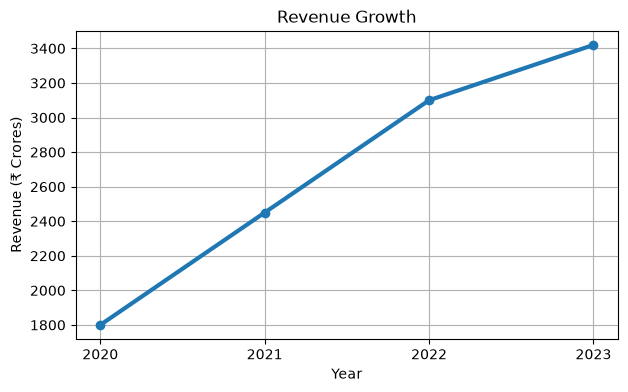

In [17]:
import matplotlib.pyplot as plt

years = ["2020", "2021", "2022", "2023"]
revenue = [1800, 2450, 3100, 3420]

plt.figure(figsize=(7,4))
plt.plot(years, revenue, marker="o", linewidth=3)
plt.title("Revenue Growth")
plt.xlabel("Year")
plt.ylabel("Revenue (₹ Crores)")
plt.grid(True)

plt.savefig("chart1.png", dpi=300)
plt.show()

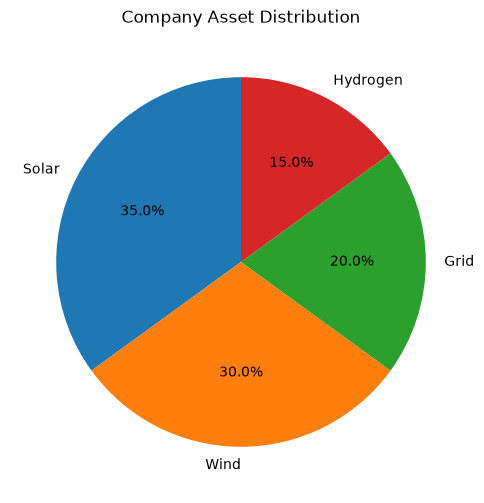

In [18]:
assets = ["Solar", "Wind", "Grid", "Hydrogen"]

values = [35, 30, 20, 15]

plt.figure(figsize=(6,6))
plt.pie(
    values,
    labels=assets,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Company Asset Distribution")

plt.savefig("chart2.png", dpi=300)
plt.show()

In [19]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image
)
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("report_output.pdf")

story = []

story.append(Paragraph("<b>Fictional Annual Report</b>", styles["Title"]))
story.append(Spacer(1,12))

for line in full_report.split("\n"):
    story.append(Paragraph(line, styles["BodyText"]))

story.append(Spacer(1,20))

story.append(Paragraph("<b>Revenue Growth</b>", styles["Heading2"]))
story.append(Image("chart1.png", width=420, height=240))

story.append(Spacer(1,20))

story.append(Paragraph("<b>Asset Distribution</b>", styles["Heading2"]))
story.append(Image("chart2.png", width=320, height=320))

doc.build(story)

print("✅ Final PDF Created Successfully!")

✅ Final PDF Created Successfully!
